In [ ]:
from cProfile import label

import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.pylabtools import figsize
from fontTools.diff import color
from matplotlib import markers, projections
from matplotlib.lines import lineStyles
# from pygments.styles.dracula import background

In [4]:
x = [1,2,3]
y = [4,5,6]

In [3]:
plt.plot(x,y)
plt.grid()
plt.show()

NameError: name 'plt' is not defined

**Pyplot API**

In [76]:
# Univeariate - Numerical

In [77]:
data = {
    "salary" : [2000,30000,55000,70000,23000,35000,44000,60000,50000,80000]
}

In [78]:
df = pd.DataFrame(data)

In [79]:
df.head()

,salary
0,2000
1,30000
2,55000
3,70000
4,23000


In [80]:
df.shape

(10, 1)

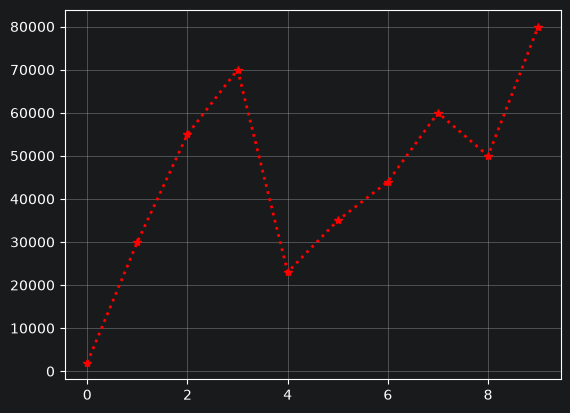

In [81]:
#Line Plot

plt.plot(df['salary'] , color = 'red', marker = "*", linestyle = ":", linewidth = '2')
plt.grid()
plt.show()

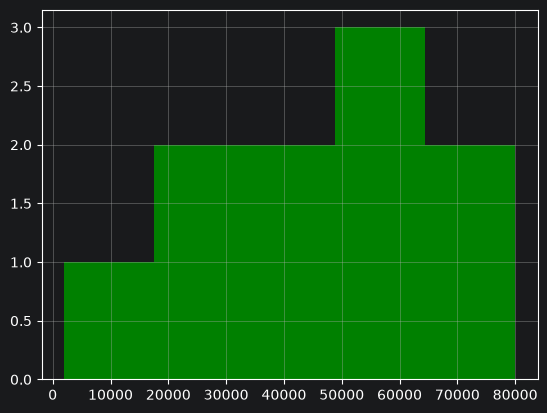

In [82]:
# Histogram

plt.hist(df['salary'],bins = 5, color = 'green')
plt.grid()
plt.show()

In [83]:
#Boxplot

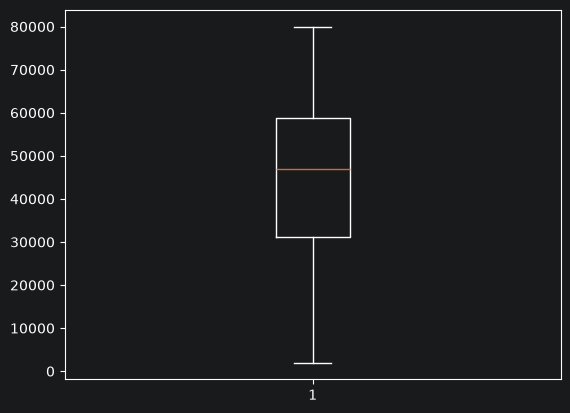

In [84]:
plt.boxplot(df['salary'])
plt.show()

In [85]:
df.shape

(10, 1)

In [86]:
#  Univariate : Categorical

In [88]:
df['dept'] =['HR','IT','Fin','HR','IT'] *2

In [89]:
df.head()

,salary,dept
0,2000,HR
1,30000,IT
2,55000,Fin
3,70000,HR
4,23000,IT


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   salary  10 non-null     int64
 1   dept    10 non-null     str  
dtypes: int64(1), str(1)
memory usage: 292.0 bytes


In [91]:
# Pie Chart
count = df['dept'].value_counts()
count

dept
HR     4
IT     4
Fin    2
Name: count, dtype: int64

(np.float64(-1.193036954353119),
 np.float64(1.2739386537906137),
 np.float64(-1.1720438649683602),
 np.float64(1.1034226957553013))

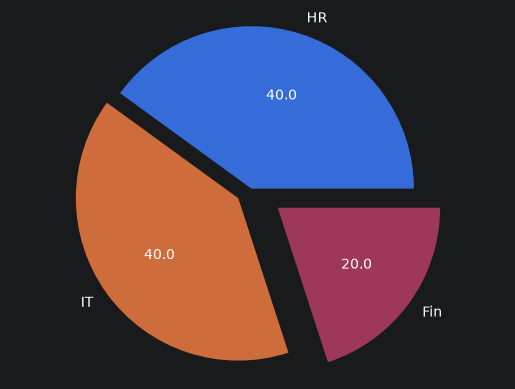

In [92]:
plt.pie(count, labels = count.index, autopct="%1.1f", explode=[0,0.1,0.2])
plt.axis("equal")

In [93]:
# Count Plot

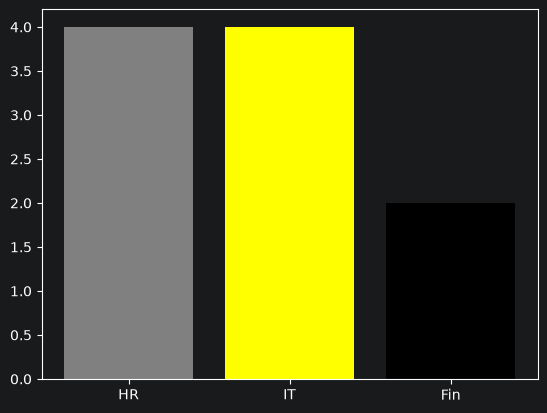

In [94]:
plt.bar(count.index, count, color = ['grey','yellow','black'])
plt.show()

In [95]:
# Bivariate - Numerical - Numerical

In [96]:
df.head()

,salary,dept
0,2000,HR
1,30000,IT
2,55000,Fin
3,70000,HR
4,23000,IT


In [98]:
df["age"] = [22,25,30,21,27,32,23,28,35,20]

In [99]:
df.head()

,salary,dept,age
0,2000,HR,22
1,30000,IT,25
2,55000,Fin,30
3,70000,HR,21
4,23000,IT,27


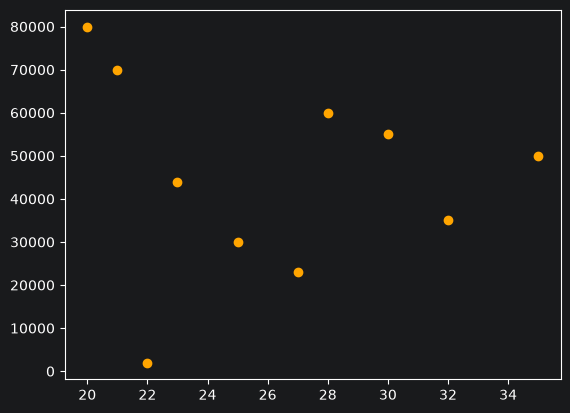

In [102]:
#Scatter Plot

plt.scatter(df['age'],df['salary'], color = 'orange')

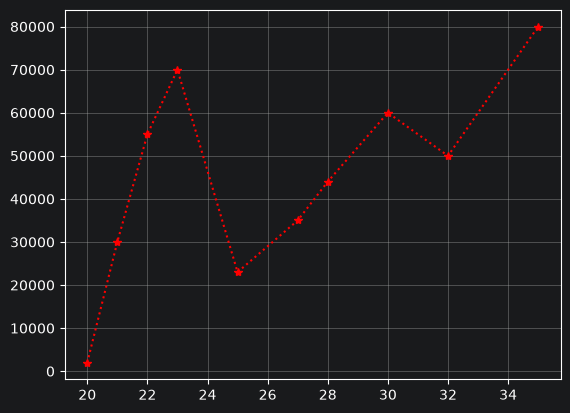

In [111]:
# Line Plot
sortAge = df.sort_values('age')
plt.plot(sortAge['age'],df['salary'] , color = 'red', marker = '*', linestyle = ':')
plt.grid()
plt.show()

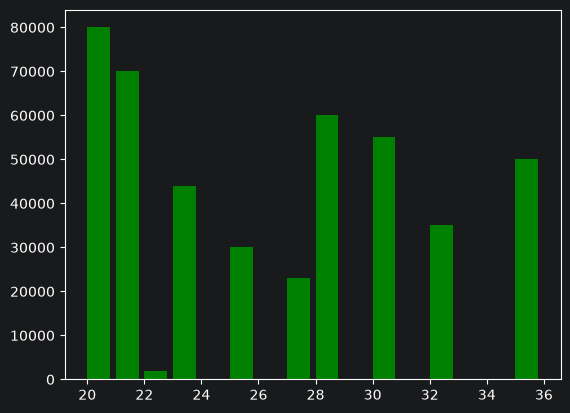

In [117]:
# Bar Chart :
plt.bar(sortAge['age'],sortAge['salary'], color = 'green', align='edge')
plt.show()

In [118]:
# Bivariate analysis : Numwrical & Categorical

In [122]:
hr_sal = df[df['dept'] == 'HR']['salary']
hr_sal

0     2000
3    70000
5    35000
8    50000
Name: salary, dtype: int64

In [123]:
It_sal = df[df['dept'] == 'IT']['salary']
It_sal

1    30000
4    23000
6    44000
9    80000
Name: salary, dtype: int64

In [124]:
fin_sal = df[df['dept'] == 'Fin']['salary']
fin_sal

2    55000
7    60000
Name: salary, dtype: int64

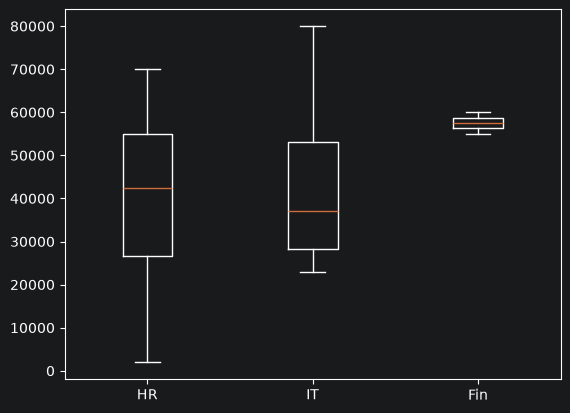

In [131]:
# BoxPlot:

plt.boxplot([hr_sal,It_sal,fin_sal], tick_labels= ['HR','IT','Fin'])
plt.show()

In [132]:
# Pie Chart

salary_by_dept = df.groupby('dept')['salary'].sum()

In [133]:
salary_by_dept

dept
Fin    115000
HR     157000
IT     177000
Name: salary, dtype: int64

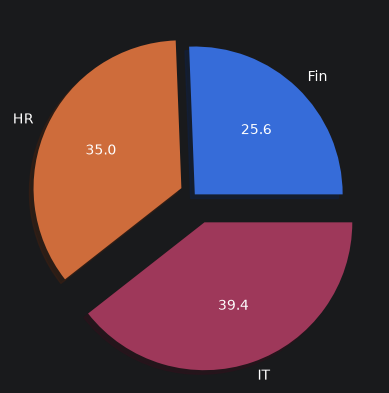

In [153]:
plt.pie(salary_by_dept, autopct="%1.1f", labels=salary_by_dept.index, shadow= True, explode=[0,0.1,0.2])

In [147]:
# # bar plot
# hr_mean = sum(hr_sal)/len(hr_sal)
# It_sal = sum(It_sal)/len(It_sal)
# fin_sal = sum(fin_sal)/len(fin_sal)
#
# plt.bar(['HR','IT','Fin'], [hr_mean, It_sal, fin_sal], color = ['blue','green','red'])
# plt.show()


In [148]:
# **Multivariate Analysis - 3 Numerical Columns

In [149]:
df['experience'] = [2,4,3,5,6,8,7,9,1,2]

In [150]:
df.head()

,salary,dept,age,experience
0,2000,HR,22,2
1,30000,IT,25,4
2,55000,Fin,30,3
3,70000,HR,21,5
4,23000,IT,27,6


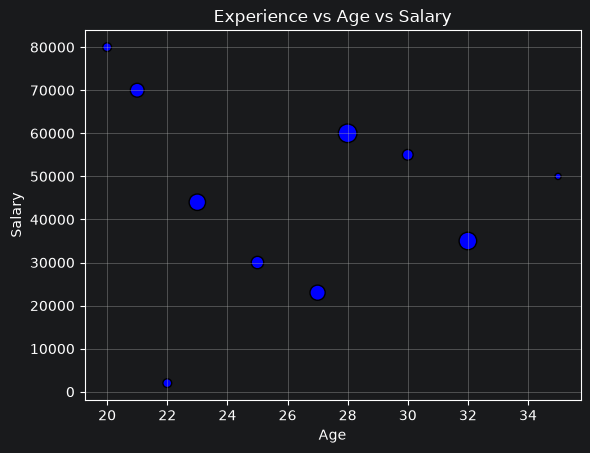

In [160]:
# Bubble Plot

plt.scatter(df['age'],df['salary'],s = df['experience']* 20, color = 'blue', edgecolors='black')
plt.title("Experience vs Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid()
plt.show()

In [161]:

# 2 Numwrical and 1 Categorical Column

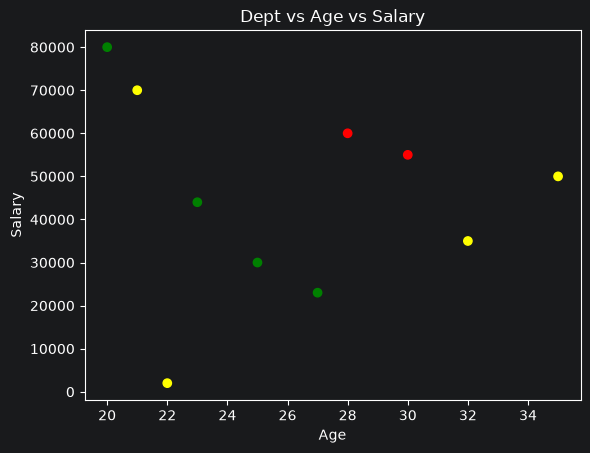

In [169]:
plt.scatter(df['age'],df['salary'], c = df['dept'].map({"HR": "yellow", "IT": "green", "Fin": "red" }))
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Dept vs Age vs Salary")
plt.show()

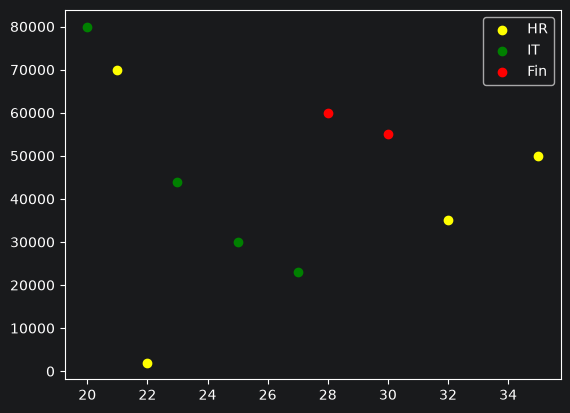

In [171]:
color = {"HR":"yellow", "IT":"green", "Fin":"red"}

for dept, color in color.items():
    df_dept = df[df['dept'] == dept]
    plt.scatter(df_dept["age"], df_dept["salary"], c = color, label = dept)
    plt.legend()

In [172]:
# Object Oriented API

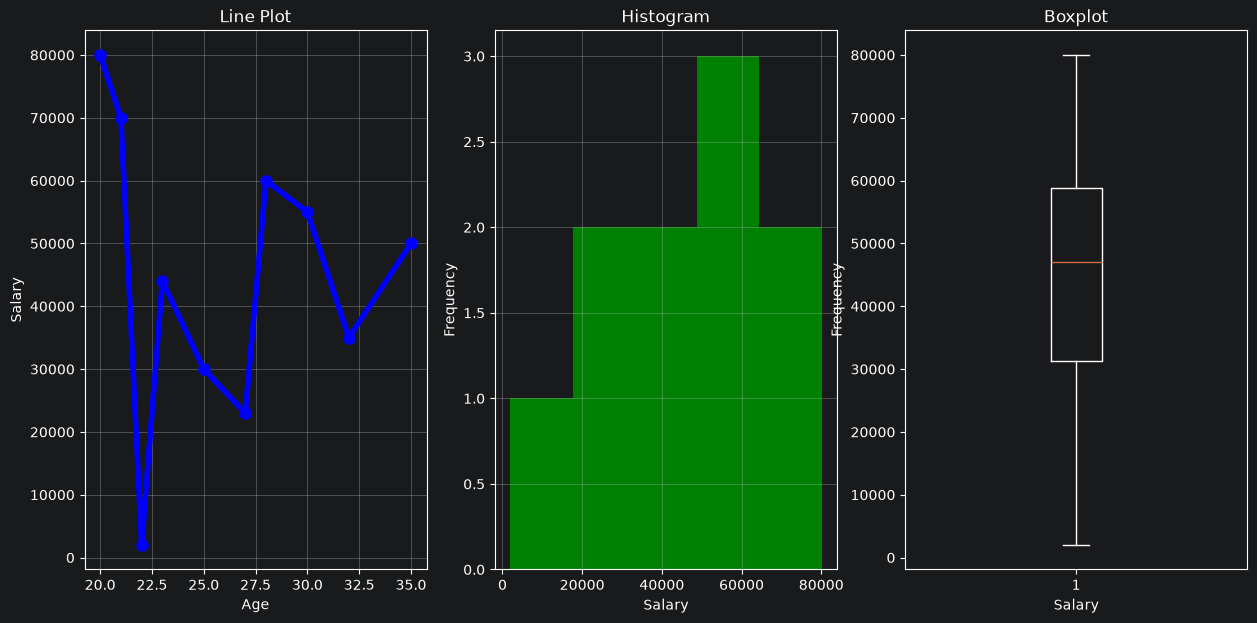

In [186]:
# Line plot


fig, axs = plt.subplots(1,3 ,figsize = (15,7))

axs[0].plot(sortAge['age'],sortAge['salary'], color = 'blue', marker = "o", linewidth = '4',markersize = 8)
axs[0].grid()
axs[0].set_title("Line Plot")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Salary")


# Histogram
axs[1].hist(df['salary'],bins = 5, color = 'green')
axs[1].grid()
axs[1].set_title("Histogram")
axs[1].set_xlabel("Salary")
axs[1].set_ylabel("Frequency")

# BoxPlot
axs[2].boxplot(df['salary'])
axs[2].set_title("Boxplot")
axs[2].set_xlabel("Salary")
axs[2].set_ylabel("Frequency")

plt.savefig("multipleplots.png")

plt.show()



In [190]:
data = {
    'year' : [2020,2021,2022,2023],
    'sales' : [100,150,200,250],
    'Profit' : [20,10,40,50],
    'Expenses' : [80,120,160,200]
}

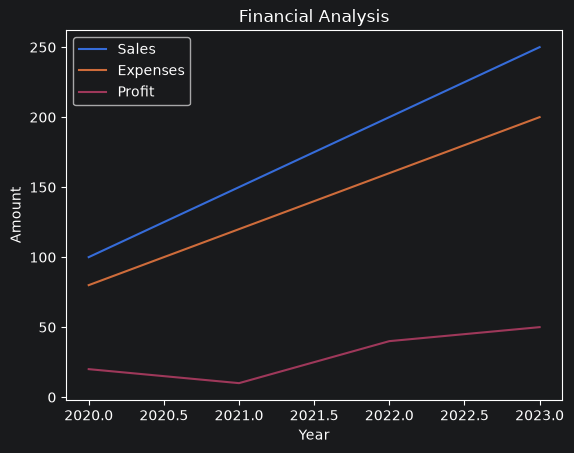

In [191]:
df2 = pd.DataFrame(data)

plt.plot(df2['year'], df2['sales'], label = 'Sales')
plt.plot(df2['year'], df2['Expenses'], label = 'Expenses')
plt.plot(df2['year'], df2['Profit'], label = 'Profit')

plt.title("Financial Analysis")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.show()

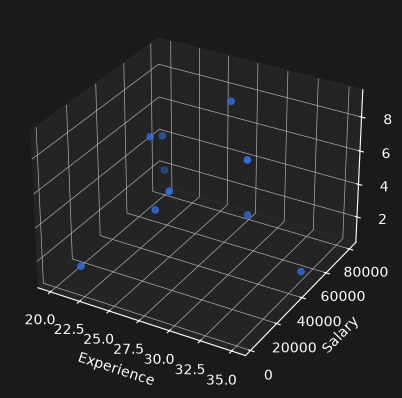

In [197]:
ax = plt.axes(projection = "3d")

ax.scatter(df['age'], df['salary'], df['experience'])
ax.set_xlabel("Age")
ax.set_ylabel("Salary")
ax.set_xlabel("Experience")
plt.show()

In [203]:
import plotly.express as px

In [204]:
fig = px.scatter_3d(df,x='age', y='salary', z='experience',
                    color = 'age', title="3d Plot")

In [206]:
fig.show()